# quoFEM Sensitivity Analysis Example using DAPI

Pedro Arduino - UW Computational Geomechanics Group

Aakash B. Satish & Sangri Yi - SimCenter, UC Berkeley

This example shows how to run a quoFEM global sensitivity analysis on DesignSafe from a Jupyter notebook using the DesignSafe API ([dapi](https://github.com/DesignSafe-CI/dapi)), and how to postprocess the results in Python.

The workflow submits the SimCenter UQ application (`simcenter-uq-stampede3`) to TACC Stampede3. The app takes:

- an **input directory** (`DS_input`) containing the quoFEM working files (`tmp.SimCenter/templatedir/` with `scInput.json`, the `driver` script, and the OpenSees model files),
- two environment variables: `inputFile` (the quoFEM workflow JSON, `scInput.json`) and `driverFile` (the per-sample execution script, `driver`).

The analysis performs Monte Carlo sampling (500 samples) of three PM4Sand constitutive model parameters (`Dr`, `G0`, `hpo`) in a cyclic direct simple shear simulation and reports the sensitivity of the number-of-cycles engineering demand parameters (EDPs).

**Note: This example takes roughly 30-45 minutes end-to-end on Stampede3 (`skx-dev` queue), much of it queue time.**

**Note: Executing this notebook requires a TACC allocation, set in `tacc_allocation`. Please contact DesignSafe/TACC to obtain an allocation.**

# Setup DAPI and start quoFEM job

In [1]:
%pip install dapi --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

In [3]:
# Import DAPI and other required libraries
from dapi import DSClient
import os
import json

In [4]:
try:
    ds = DSClient()
except Exception as e:
    print(f"Authentication failed: {e}")
    raise SystemExit("Stopping notebook due to authentication failure.")

Authentication successful.
DatabaseAccessor initialized. Connections will be created on first access.
TMS credentials ready: frontera, stampede3, ls6


### Setup job description

In [5]:
# Job configuration parameters
job_name: str = "quofem-sensitivity-dapi"
app_id: str = "simcenter-uq-stampede3"
input_filename: str = (
    "scInput.json"  # quoFEM workflow JSON in tmp.SimCenter/templatedir
)
driver_filename: str = "driver"  # per-sample execution script
tacc_allocation: str = "DS-Portal-SPARC2026"  # MUST USE YOUR OWN ALLOCATION !!
archive_system: str = "designsafe"  # archive to MyData (default path)
archive_path = None

# To archive into a shared DesignSafe project instead (so collaborators can see
# the job and its outputs), point archive_system at the project system id:
# archive_system = "project-8332570396718076396-242ac118-0001-012"
# archive_path = f"quoFEM_jobs/{job_name}"
queue: str = "skx-dev"
node_count: int = 1
cores_per_node: int = 48
memory_mb: int = 128000
max_job_minutes: int = 120

# SimCenter backend installation on Stampede3 used by the app
sc_backend_dir: str = (
    "/work2/00477/tg457427/stampede3/SimCenterBackendApplications/v26.05.26"
)

In [6]:
ds_path = os.getcwd() + "/DS_input"
print(f"DesignSafe path: {ds_path}")
input_uri = ds.files.to_uri(ds_path)
print(f"Input URI: {input_uri}")

DesignSafe path: /home/jupyter/MyData/template-notebooks/quoFEM-sensitivity/DS_input
Translated '/home/jupyter/MyData/template-notebooks/quoFEM-sensitivity/DS_input' to 'tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input' using t.username
Input URI: tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input


### Point `scInput.json` at the SimCenter backend on Stampede3

The quoFEM desktop application writes local paths into `scInput.json`. Before submitting, update `remoteAppDir` and `remoteAppWorkingDir` to the SimCenter backend installation on the execution system.

In [7]:
sc_input_path = os.path.join(ds_path, "tmp.SimCenter", "templatedir", input_filename)

with open(sc_input_path, "r") as f:
    sc_input = json.load(f)

sc_input["remoteAppDir"] = sc_backend_dir
sc_input["remoteAppWorkingDir"] = sc_backend_dir

with open(sc_input_path, "w") as f:
    json.dump(sc_input, f, indent=2)

rv_names = [rv["name"] for rv in sc_input["randomVariables"]]
edp_names = [edp["name"] for edp in sc_input["EDP"]]

print(f"Updated remoteAppDir in {sc_input_path}")
print(f"UQ engine: {sc_input['UQ']['uqEngine']} ({sc_input['UQ']['uqType']})")
print(f"Random variables: {rv_names}")
print(f"EDPs: {edp_names}")

Updated remoteAppDir in /home/jupyter/MyData/template-notebooks/quoFEM-sensitivity/DS_input/tmp.SimCenter/templatedir/scInput.json
UQ engine: SimCenterUQ (Sensitivity Analysis)
Random variables: ['Dr', 'G0', 'hpo']
EDPs: ['nCycles010_1', 'nCycles010_2', 'nCycles013', 'nCycles015', 'nCycles017', 'nCycles020']


### Generate job request

In [8]:
# Generate job request dictionary using app defaults
job_dict = ds.jobs.generate(
    app_id=app_id,
    input_dir_uri=input_uri,
    archive_system=archive_system,
    archive_path=archive_path,
    max_minutes=max_job_minutes,
    allocation=tacc_allocation,
    queue=queue,
    job_name=job_name,
    node_count=node_count,
    cores_per_node=cores_per_node,
    memory_mb=memory_mb,
    extra_env_vars=[
        {"key": "inputFile", "value": input_filename},
        {"key": "driverFile", "value": driver_filename},
    ],
)

# The SimCenter wrapper script requires the staged input directory to be
# exposed as the $inputDirectory environment variable and unpacked into the
# job working directory. The app definition declares no fileInputs, so
# generate() cannot detect this automatically.
job_dict["fileInputs"][0]["envKey"] = "inputDirectory"
job_dict["fileInputs"][0]["targetPath"] = "*"

print("Generated job request:")
print(json.dumps(job_dict, indent=2, default=str))

Generating job request for app 'simcenter-uq-stampede3'...
Using App Details: simcenter-uq-stampede3 v2.0.0
script_filename is None, skipping script parameter placement.
Adding/Updating TACC allocation: DS-Portal-SPARC2026
Job request dictionary generated successfully.
Generated job request:
{
  "name": "quofem-sensitivity-dapi",
  "appId": "simcenter-uq-stampede3",
  "appVersion": "2.0.0",
  "description": "simcenter-uq on Stampede3",
  "execSystemId": "stampede3",
  "archiveSystemId": "designsafe.storage.default",
  "archiveSystemDir": "${EffectiveUserId}/tapis-jobs-archive/${JobCreateDate}/${JobUUID}",
  "archiveOnAppError": true,
  "execSystemLogicalQueue": "skx-dev",
  "nodeCount": 1,
  "coresPerNode": 48,
  "maxMinutes": 120,
  "memoryMB": 128000,
  "isMpi": false,
  "tags": [],
  "fileInputs": [
    {
      "name": "Input Directory",
      "sourceUrl": "tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input",
      "autoMountLocal": true,
      "

### Run job

In [9]:
# Submit job using dapi
submitted_job = ds.jobs.submit(job_dict)
print(f"Job launched with UUID: {submitted_job.uuid}")
print(
    "Can also check in DesignSafe portal under - Workspace > Tools & Application > Job Status"
)


--- Submitting Tapis Job Request ---
{
  "name": "quofem-sensitivity-dapi",
  "appId": "simcenter-uq-stampede3",
  "appVersion": "2.0.0",
  "description": "simcenter-uq on Stampede3",
  "execSystemId": "stampede3",
  "archiveSystemId": "designsafe.storage.default",
  "archiveSystemDir": "${EffectiveUserId}/tapis-jobs-archive/${JobCreateDate}/${JobUUID}",
  "archiveOnAppError": true,
  "execSystemLogicalQueue": "skx-dev",
  "nodeCount": 1,
  "coresPerNode": 48,
  "maxMinutes": 120,
  "memoryMB": 128000,
  "isMpi": false,
  "tags": [],
  "fileInputs": [
    {
      "name": "Input Directory",
      "sourceUrl": "tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input",
      "autoMountLocal": true,
      "envKey": "inputDirectory",
      "targetPath": "*"
    }
  ],
  "parameterSet": {
    "envVariables": [
      {
        "key": "inputFile",
        "value": "scInput.json"
      },
      {
        "key": "driverFile",
        "value": "driver"
      }
   

In [10]:
# Monitor job status using dapi
final_status = submitted_job.monitor(interval=30)
print(f"Job finished with status: {final_status}")

# Interpret job status
ds.jobs.interpret_status(final_status, submitted_job.uuid)

# Display runtime summary
submitted_job.print_runtime_summary(verbose=False)


Monitoring Job: 221f9d0b-5040-4298-8520-3386b1cf6ebb-007


Waiting for job to start: 0 checks [00:00, ? checks/s]

Monitoring job:   0%|          | 0/240 [00:00<?, ? checks/s]

	Status: RUNNING
	Status: ARCHIVING
	Status: FINISHED
Job finished with status: FINISHED
Job 221f9d0b-5040-4298-8520-3386b1cf6ebb-007 completed successfully.

Runtime Summary
---------------
QUEUED  time: 00:00:12
RUNNING time: 00:16:22
TOTAL   time: 00:28:54
---------------


In [11]:
# Print out last message from the job
print(submitted_job.last_message)

Setting job status to FINISHED.


# Postprocess Results

### Identify job and archived location

In [13]:
# Get archive information using dapi
archive_uri = submitted_job.archive_uri
print(f"Archive URI: {archive_uri}")

# List archive contents
archive_files = ds.files.list(archive_uri)
print("\nArchive contents:")
for item in archive_files:
    print(f"- {item.name} ({item.type})")

Archive URI: tapis://designsafe.storage.default/kks32/tapis-jobs-archive/2026-08-07Z/221f9d0b-5040-4298-8520-3386b1cf6ebb-007
Listing files in system 'designsafe.storage.default' at path 'kks32/tapis-jobs-archive/2026-08-07Z/221f9d0b-5040-4298-8520-3386b1cf6ebb-007'...
Found 11 items.

Archive contents:
- app.json (file)
- app.zip (file)
- DS_input (dir)
- results.zip (file)
- submit.json (file)
- tapisjob.env (file)
- tapisjob.out (file)
- tapisjob.sh (file)
- tapisjob_app.sh (file)
- templatedir.zip (file)
- workdir.tar.gz (file)


### Retrieve the UQ results

The app wrapper gathers the UQ engine outputs (`dakota.out`, `dakotaTab.out`, `dakota.err`) into **`results.zip`** in the archive root, alongside `templatedir.zip` and (when per-sample workdirs are kept) `workdir.tar.gz`. Fetch the zip and read the results in memory.

In [14]:
import io
import zipfile

details = submitted_job.details
zip_bytes = ds.tapis.files.getContents(
    systemId=details.archiveSystemId,
    path=f"{details.archiveSystemDir}/results.zip",
    stream=True,
)
results_zip = zipfile.ZipFile(io.BytesIO(zip_bytes))
print("results.zip contents:", results_zip.namelist())

results.zip contents: ['results/', 'results/dakota.err', 'results/dakota.out', 'results/dakotaTab.out']


In [15]:
import pandas as pd


def read_result(zf: zipfile.ZipFile, filename: str) -> bytes:
    """Read a file from the results archive by basename."""
    name = next(n for n in zf.namelist() if n.endswith(filename))
    return zf.read(name)


samples = pd.read_csv(io.BytesIO(read_result(results_zip, "dakotaTab.out")), sep=r"\s+")
print(f"{len(samples)} samples, columns: {list(samples.columns)}")
samples.head()

500 samples, columns: ['idx', 'Dr', 'G0', 'hpo', 'nCycles010_1', 'nCycles010_2', 'nCycles013', 'nCycles015', 'nCycles017', 'nCycles020']


,idx,Dr,G0,hpo,nCycles010_1,nCycles010_2,nCycles013,nCycles015,nCycles017,nCycles020
0,1,0.208492,984.40269,2.750463,12.25,12.25,4.50,2.50,1.50,0.50
1,2,0.186365,796.35018,2.275522,8.50,8.50,3.50,1.50,1.25,0.50
2,3,0.429658,749.44646,0.558715,20.25,20.25,9.50,6.25,4.25,3.25
3,4,0.408158,1439.90920,1.427896,41.25,41.25,19.50,12.50,8.50,6.25
4,5,0.341304,379.37589,2.486818,30.25,30.25,12.25,6.50,3.50,2.25


### Monte Carlo samples of the random variables

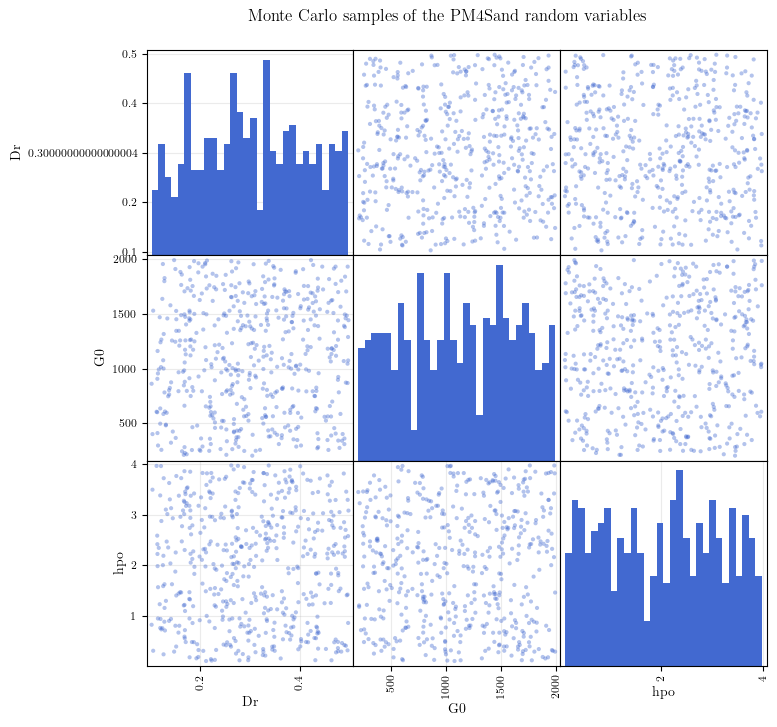

In [16]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

axes = scatter_matrix(
    samples[rv_names],
    figsize=(8, 8),
    diagonal="hist",
    color="#4269d0",
    alpha=0.4,
    hist_kwds={"color": "#4269d0", "bins": 30},
)
for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
plt.suptitle("Monte Carlo samples of the PM4Sand random variables", y=0.93)
plt.show()

### Distributions of the engineering demand parameters

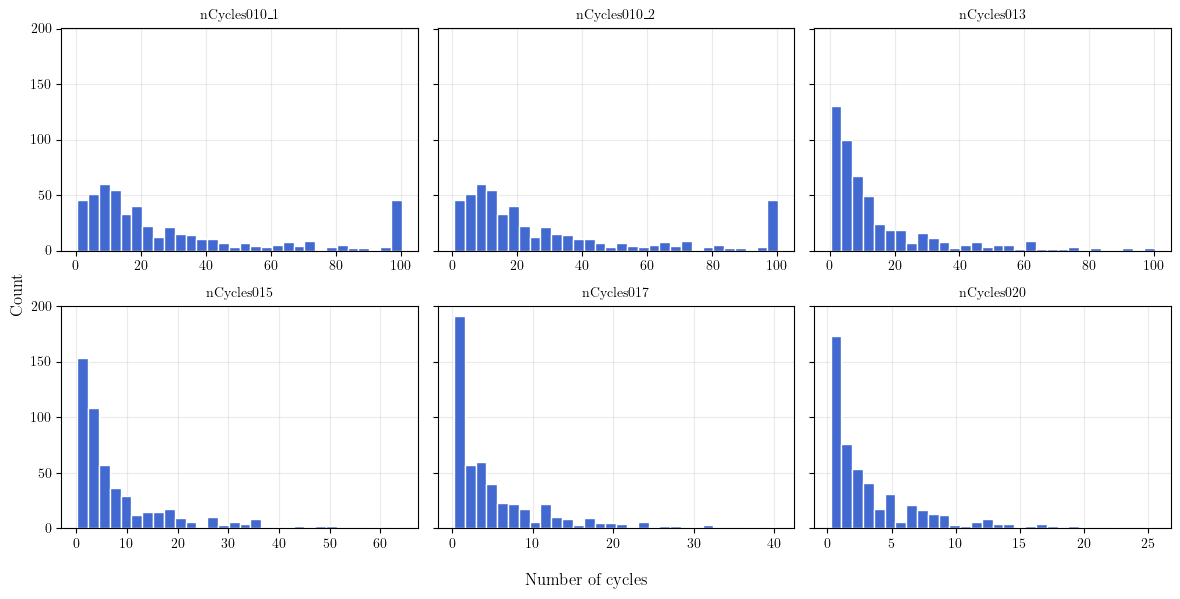

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, edp in zip(axes.ravel(), edp_names):
    ax.hist(samples[edp], bins=30, color="#4269d0", edgecolor="white")
    ax.set_title(edp, fontsize=10)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
fig.supxlabel("Number of cycles")
fig.supylabel("Count")
fig.tight_layout()
plt.show()

### Sensitivity indices

In [18]:
# The Sobol sensitivity indices are reported in dakota.out
print(read_result(results_zip, "dakota.out").decode())

* data generation
Monte Carlo
* number of input combinations
3
* input names
Dr
G0
hpo
* number of aggregated outputs
0
* number of outputs
6
* output names
nCycles010_1
nCycles010_2
nCycles013
nCycles015
nCycles017
nCycles020
* Sm(Dr) Sm(G0) Sm(hpo) St(Dr) St(G0) St(hpo) 
0.70525205 0.02077442 0.20214571 0.74348871 0.02077442 0.20653809 
0.70525205 0.02077442 0.20214571 0.74348871 0.02077442 0.20653809 
0.73873876 0.04916962 0.15228061 0.77498626 0.04916962 0.15228061 
0.70351878 0.07439568 0.12992313 0.78637324 0.07439568 0.12992313 
0.72505227 0.08913956 0.11512433 0.72505227 0.08913956 0.11512433 
0.72471853 0.13453042 0.08946293 0.76726225 0.13453042 0.08946293 
* number of samples
500
* elapsed time:
653.77600000 s
* PCA
no

